In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

# Load dataset
dataset = pd.read_csv("Data/Ads_CTR_Optimisation.csv")

In [5]:
N = 10000   # number of rounds
d = 10      # number of ads

ads_selected = []

numbers_of_rewards_1 = [0] * d   # number of clicks
numbers_of_rewards_0 = [0] * d   # number of no-clicks

total_reward = 0

In [6]:
for n in range(0, N):

    ad = 0
    max_random = 0

    for i in range(0, d):

        random_beta = random.betavariate(
            numbers_of_rewards_1[i] + 1,
            numbers_of_rewards_0[i] + 1
        )

        if random_beta > max_random:
            max_random = random_beta
            ad = i

    ads_selected.append(ad)

    reward = dataset.values[n, ad]

    if reward == 1:
        numbers_of_rewards_1[ad] += 1
    else:
        numbers_of_rewards_0[ad] += 1

    total_reward += reward

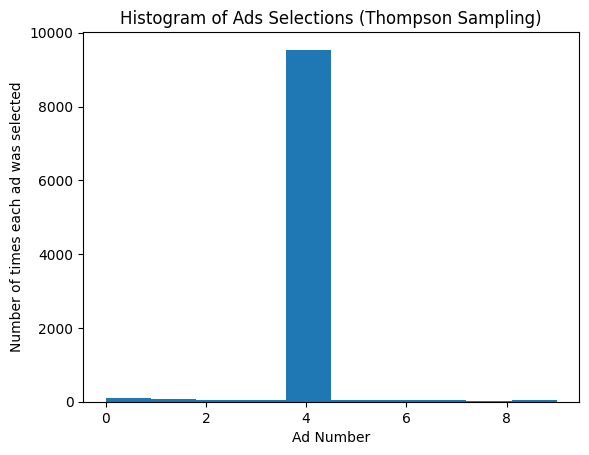

In [7]:

# Visualization
plt.hist(ads_selected)
plt.title("Histogram of Ads Selections (Thompson Sampling)")
plt.xlabel("Ad Number")
plt.ylabel("Number of times each ad was selected")
plt.show()